# This notebook is a part of the LASSO updraft width resolution sensitivity paper
## It makes the following plot:
- Spatial distribution of tracked cell frequency over the SDC terrain with OBS vs. LASSO at 3 resolutions (2.5 km, 500 m, 100 m)
- Bar chart with averaged number of tracked cells per case date with OBS vs. LASSO (with error bar for LASSO ensemble members)
## The cell tracking data used in the notebook is directly produced by PyFLEXTRKR.
- OBS: original CSAPR2 Cartesian files and cell track stats files are needed
- LASSO: WRF subset `cldamsl` files are used to count the total number of valid "scan" times for normalizing cell frequency, cell tracking stats files are also needed

In [ ]:
import os, fnmatch
import datetime, calendar
from pytz import utc
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr
import pandas as pd
import datetime
import copy
import warnings

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [ ]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    # "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/obs_lasso_evaluation/'

# CSAPR data directory
dir_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/'
dir_obs25 = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/'
dir_pixel_obs25 = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_gridded.c1/'
dir_pixel_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqcM1_gridded_convmask.c1/'
terrain_file = f'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/corgridded_terrain.c0/topo_cacti_csapr2_large.nc'
radar_lat = -32.1264
radar_lon = -64.7284
# Start/end hours for OBS
# shour_obs = '12'
# ehour_obs = '00'

# basename_obs = 'csapr_trackstats_'
basename_obs = 'trackstats_'
basename_obs25 = 'trackstats_'

statsfiles_obs = []
statsfiles_obs25 = []
for idate in start_dates:
    statsfiles_obs.extend(sorted(glob.glob(f'{dir_obs}{basename_obs}{idate}*nc')))
    statsfiles_obs25.extend(sorted(glob.glob(f'{dir_obs25}{basename_obs25}{idate}*nc')))

print(f'Number of cases (OBS): {len(statsfiles_obs)}')
print(f'Number of cases (OBS 2.5km): {len(statsfiles_obs25)}')
statsfiles_obs, statsfiles_obs25

Number of cases (OBS): 8
Number of cases (OBS 2.5km): 8


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190122.1200_20190123.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190123.1200_20190124.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190125.1200_20190126.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfr

In [4]:
# LASSO regridded cloud file basename for calculating total "scan" times
# cld_basename = 'corlasso.cldhamsl.'
cld_basename = 'corlasso_cldhamsl_'

# LASSO tracking directory
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
# LASSO staged data directory
lassodir = '/gpfs/wolf2/arm/cli120/world-shared/d3m088/cacti/staged_runs/'
in_basename = 'trackstats_20'

# Domain 4 boundaries
lon_range = [-65.4, -63.1]
lat_range = [-33.3, -30.8]

# Find LASSO files
# statsfiles_d2 = find_lasso_stats_files(start_dates, rootdir_meso, in_basename, 'd2')
# statsfiles_d3 = find_lasso_stats_files(start_dates, rootdir_les, in_basename, 'd3')
# statsfiles_d4 = find_lasso_stats_files(start_dates, rootdir_les, in_basename, 'd4_15min')
statsfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2_15min')
statsfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3_15min')
statsfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4_15min')

print(f'Number of stats files (D2): {len(statsfiles_d2)}')
print(f'Number of stats files (D3): {len(statsfiles_d3)}')
print(f'Number of stats files (D4): {len(statsfiles_d4)}')
statsfiles_d2, statsfiles_d3, statsfiles_d4

Number of stats files (D2): 17
Number of stats files (D3): 17
Number of stats files (D4): 17


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base/d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base/d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base/d2_15min/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cact

## Functions to count radar scan times

In [5]:
def get_obs_filetimes(
    data_path,
    data_basename,
    time_format="yyyymodd_hhmm",
):
    """
    Calculate base time (Epoch time) from filenames.

    Args:
        data_path: string
            Data directory name.
        data_basename: string
            Data base name.
        time_format: string (optional, default="yyyymodd_hhmm")
            Specify file time format to extract date/time.
    Returns:
        data_filenames: list
            List of data filenames.
        files_basetime: numpy array
            Array of file base time.
        files_datestring: list
            List of file date string.
        files_timestring: list
            List of file time string.

    """
    # logger = logging.getLogger(__name__)
    # Isolate all possible files
    filenames = sorted(fnmatch.filter(os.listdir(data_path), data_basename + '*'))

    # Loop through files, identifying files within the startdate - enddate interval
    nleadingchar = len(data_basename)

    data_filenames = [None]*len(filenames)
    files_timestring = [None]*len(filenames)
    files_datestring = [None]*len(filenames)
    files_basetime = np.full(len(filenames), -9999, dtype=int)
    files_datetime = []

    yyyy_idx = time_format.find("yyyy")
    mo_idx = time_format.find("mo")
    dd_idx = time_format.find("dd")
    hh_idx = time_format.find("hh")
    mm_idx = time_format.find("mm")
    ss_idx = time_format.find("ss")

    # Add basetime character counts to get the actual date/time string positions
    yyyy_idx = nleadingchar + yyyy_idx
    mo_idx = nleadingchar + mo_idx
    dd_idx = nleadingchar + dd_idx
    hh_idx = nleadingchar + hh_idx if (hh_idx != -1) else None
    mm_idx = nleadingchar + mm_idx if (mm_idx != -1) else None
    ss_idx = nleadingchar + ss_idx if (ss_idx != -1) else None

    # Loop over each file
    for ii, ifile in enumerate(filenames):
        year = ifile[yyyy_idx:yyyy_idx+4]
        month = ifile[mo_idx:mo_idx+2]
        day = ifile[dd_idx:dd_idx+2]
        # If hour, minute, second is not in time_format, assume 0
        hour = ifile[hh_idx:hh_idx+2] if (hh_idx is not None) else '00'
        minute = ifile[mm_idx:mm_idx+2] if (mm_idx is not None) else '00'
        second = ifile[ss_idx:ss_idx+2] if (ss_idx is not None) else '00'

        # Check month, day, hour, minute, second valid values
        if (0 <= int(month) <= 12) & (0 <= int(day) <= 31) & \
           (0 <= int(hour) <= 23) & (0 <= int(minute) <= 59) & (0 <= int(second) <= 59):
            TEMP_filetime = datetime.datetime(int(year), int(month), int(day),
                                            int(hour), int(minute), int(second), tzinfo=utc)
            files_basetime[ii] = calendar.timegm(TEMP_filetime.timetuple())
            TEMP_timestamp = pd.to_datetime(f'{year}{month}{day}.{hour}{minute}{second}', format='%Y%m%d.%H%M%S')
            files_datetime.append(TEMP_timestamp)
        else:
            print(f'File has invalid date/time, will not be included in processing: {ifile}')
            pass
        files_datestring[ii] = year + month + day
        files_timestring[ii] = hour + minute
        data_filenames[ii] = data_path + ifile
    files_datetime = np.array(files_datetime)
    return (
        # data_filenames,
        files_basetime,
        files_datetime,
        # files_datestring,
        # files_timestring,
    )

def count_times_obs(statsfiles, filetimes):
    """
    Count total times for observations
    
    Args:
        statsfiles: list
            List containing stats file names
        filetimes: list
            List containing all file times
            
    Return:
        out_ntimes: int
            Total number of times
    """
    out_ntimes = 0
    # Loop over dates
    for ff in statsfiles:
        # Get start/end times from track stats attribute
        ds = xr.open_dataset(ff)
        _sdate = pd.to_datetime(ds.attrs['startdate'], format='%Y%m%d.%H%M')
        _edate = pd.to_datetime(ds.attrs['enddate'], format='%Y%m%d.%H%M')
        # Count times within the track period
        _ntimes = np.count_nonzero((filetimes >= _sdate) & (filetimes <= _edate))
        # Add counts
        out_ntimes += _ntimes
        print(ff, _ntimes)

    print(f'Total ntimes: {out_ntimes}')
    return out_ntimes

## Count total number of radar scan times from convective masks

In [6]:
# Get datetimes from OBS pixel files
basename_obs = 'taranis_corcsapr2cfrppiqcM1_convmask.c1.'
basetimes_obs, filetimes_obs = get_obs_filetimes(dir_pixel_obs, basename_obs, time_format="yyyymodd_hhmmss")

In [7]:
# Get datetimes from OBS 2.5km pixel files
basename_obs25 = 'taranis_corcsapr2cfrppiqc2500mM1.c1.'
basetimes_obs25, filetimes_obs25 = get_obs_filetimes(dir_pixel_obs25, basename_obs25, time_format="yyyymodd_hhmmss")

In [8]:
# Count total scan times (OBS 500m)
ntimes_o = count_times_obs(statsfiles_obs, filetimes_obs)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181129.1200_20181130.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181204.1200_20181205.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181205.1200_20181206.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190122.1200_20190123.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190123.1200_20190124.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190125.1200_20190126.0000.nc 29
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_cel

In [9]:
# Count total scan times (OBS 2.5km)
ntimes_o25 = count_times_obs(statsfiles_obs25, filetimes_obs25)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181129.1200_20181130.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181204.1200_20181205.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181205.1200_20181206.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190122.1200_20190123.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190123.1200_20190124.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190125.1200_20190126.0000.nc 29
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500

## Functions to count LASSO file times (equivalent to radar scan times)

In [10]:
def count_times_lasso(statsfiles, frequency):
    """
    Count total times for all LASSO ensemble runs
    
    Args:
        statsfiles: list
            List containing stats file names
        frequency: string
            Frequency to generate time series
            
    Return:
        out_ntimes: int
            Total number of times
    """
    out_ntimes = 0
    for ff in range(len(statsfiles)):
        # Get start/end times from track stats attribute
        ds = xr.open_dataset(statsfiles[ff])
        _sdate = pd.to_datetime(ds.attrs['startdate'], format='%Y%m%d.%H%M')
        _edate = pd.to_datetime(ds.attrs['enddate'], format='%Y%m%d.%H%M')
        # Generate times within the track period based on input frequency
        _datetimes = pd.date_range(_sdate, _edate, freq=frequency)
        # Count times within the track period
        _ntimes = len(_datetimes)
        print(statsfiles[ff], _ntimes)
        # Add 
        out_ntimes += _ntimes

    print(f'Total ntimes: {out_ntimes}')
    return out_ntimes

## Count LASSO "scan" times

In [11]:
# Get LASSO file datetimes (d2)
freq_d2 = '15min'
ntimes_d2 = count_times_lasso(statsfiles_d2, freq_d2)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base/d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base/d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base/d2_15min/stats/trackstats_20181205.1200_20181206.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20190122/

In [12]:
# Count d3 scan times
freq_d3 = '15min'
ntimes_d3 = count_times_lasso(statsfiles_d3, freq_d3)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs03/base/d3_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs18/base/d3_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs00/base/d3_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs09/base/d3_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181204/gefs19/base/d3_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181204/gefs18/base/d3_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181205/gefs01/base/d3_15min/stats/trackstats_20181205.1200_20181206.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20190122/gefs18/b

In [13]:
# Count d4 scan times
freq_d4 = '15min'
ntimes_d4 = count_times_lasso(statsfiles_d4, freq_d4)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs03/base/d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs18/base/d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs00/base/d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs09/base/d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181204/gefs19/base/d4_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181204/gefs18/base/d4_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181205/gefs01/base/d4_15min/stats/trackstats_20181205.1200_20181206.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20190122/gefs18/b

### Read topography file

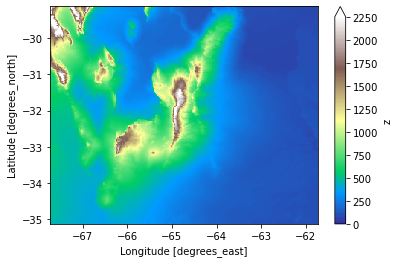

In [14]:
terr = xr.open_dataset(terrain_file)
topoZ = terr['z']
topoLon = terr['x']
topoLat = terr['y']
topoZ.plot(vmin=0, vmax=2250, cmap='terrain')

## Read, subset, combine track stats files

In [15]:
def subset_tracks(ds, lon_range, lat_range, hours_range=(12, 23.99)):
    """
    Subset tracks based on spatial and temporal criteria.
    
    Args:
        ds: xarray.Dataset
            Track statistics dataset
        lon_range: tuple
            Longitude range (min, max)
        lat_range: tuple
            Latitude range (min, max)
        hours_range: tuple
            Start hour range (min, max)
    
    Returns:
        dsout: xarray.Dataset
            Subsetted dataset
        track_idx: numpy.ndarray
            Track indices that meet criteria
    """
    # Get track min/max lat/lon
    minlon = ds['meanlon'].min(dim='times').load()
    maxlon = ds['meanlon'].max(dim='times').load()
    minlat = ds['meanlat'].min(dim='times').load()
    maxlat = ds['meanlat'].max(dim='times').load()
    # Get track start time in decimal [hours]
    start_hour = (ds['start_basetime'].dt.hour + ds['start_basetime'].dt.minute/60.).load()
    # Get track indices
    track_idx = np.where(
        (minlon >= np.min(lon_range)) & (maxlon <= np.max(lon_range)) & \
        (minlat >= np.min(lat_range)) & (maxlat <= np.max(lat_range)) & \
        (start_hour >= np.min(hours_range)) & (start_hour <= np.max(hours_range))
    )[0]
    # Subset tracks
    dsout = ds.isel(tracks=track_idx)
    return dsout, track_idx


def get_casename(in_file):
    """
    Get case date, ensemble member, and config from full filename.
    
    Args:
        in_file: str
            Full file path
    
    Returns:
        caseconfig: str
            Configuration name
        ensmember: str
            Ensemble member name
        casedate: str
            Case date (YYYYMMDD)
    """
    # Example file name with file directory:
    # .../meso//20181129/gefs09/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc
    # .../les/20181129/gefs03/base//d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc 
    caseconfig = (in_file).split(os.path.sep)[-4]
    ensmember = (in_file).split(os.path.sep)[-5]
    casedate = (in_file).split(os.path.sep)[-6]
    return caseconfig, ensmember, casedate


def read_subset_combine(tfiles, lon_range, lat_range, lasso=False):
    """
    Read in subset of data and combine into a single dataset.

    Args:
        tfiles: list
            List of track stats files to read
        lon_range: tuple
            Longitude range for subsetting
        lat_range: tuple
            Latitude range for subsetting
        lasso: bool (optional, default=False)
            Whether the data is from LASSO

    Subsets based on:
    - Track inititial lat/lon
    """
    # Suppress the warning within this block only
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)

        # Make lists for the DataSets
        dst_list = []
        # List to keep track of original track numbers
        original_tracks_list = []

        # Loop over the number of files
        for ii in range(len(tfiles)):
            tfile = tfiles[ii]

            # Read tracks file
            dst = xr.open_dataset(tfile)

            if lasso:
                caseconfig, ensmember, casedate = get_casename(tfile)
                # Make casename (date-ensmember) and look up hours
                casename = f"{casedate}-{ensmember}"
                print(f'Reading LASSO file {ii}/{len(tfiles)}: {tfile} (Case: {casedate}, Member: {ensmember}, Config: {caseconfig})')
                # Add a variable case (date-forcing) to the DataSet
                dst['case'] = casename
                dst['ensmember'] = ensmember
                dst['caseconfig'] = caseconfig
                dst['date'] = pd.to_datetime(casedate, format='%Y%m%d')

            # Subset tracks
            dst_s, track_idx = subset_tracks(dst, lon_range, lat_range)
            # Store original track numbers for this subset
            original_tracks_list.append(dst_s['tracks'].values.copy())
            # Add subsetted DataSet to the list
            dst_list.append(dst_s)
        
        # Concatenate original track numbers from all cases
        original_tracks = np.concatenate(original_tracks_list)
        # Concetenante subsetted DataSets
        ds = xr.concat(dst_list, dim='tracks')
        # Renumber tracks to make it continuous
        ntracks = ds.sizes['tracks']
        ds['tracks'] = np.arange(0, ntracks)

        # Add original track numbers as a data variable (not a coordinate)
        ds['original_tracks'] = (('tracks',), original_tracks)
        ds['original_tracks'].attrs['long_name'] = 'Original track number from individual case files'
        ds['original_tracks'].attrs['description'] = 'Track numbers before renumbering for combined dataset'

    return ds


In [16]:
# Read and subset data (OBS)
ds_o = read_subset_combine(statsfiles_obs, lon_range, lat_range)
ntracks_o = ds_o.sizes['tracks']
print(f'Number of tracks (OBS): {ntracks_o}')

Number of tracks (OBS): 524


In [17]:
# Read and subset data (OBS 2.5km)
ds_o25 = read_subset_combine(statsfiles_obs25, lon_range, lat_range)
ntracks_o25 = ds_o25.sizes['tracks']
print(f'Number of tracks (OBS 2.5km): {ntracks_o25}')

Number of tracks (OBS 2.5km): 482


In [18]:
# Read data (LASSO D2)
ds_d2 = read_subset_combine(statsfiles_d2, lon_range, lat_range, lasso=True)
ntracks_d2 = ds_d2.sizes['tracks']
print(f'Number of tracks (D2): {ntracks_d2}')

Reading LASSO file 0/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs03, Config: base)
Reading LASSO file 1/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs18, Config: base)
Reading LASSO file 2/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs00, Config: base)
Reading LASSO file 3/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base/d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs09, Config: base)
Reading LASSO file 4/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base/d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc (Case: 20181204, Member: gefs19,

In [19]:
# Read data (LASSO D3)
ds_d3 = read_subset_combine(statsfiles_d3, lon_range, lat_range, lasso=True)
ntracks_d3 = ds_d3.sizes['tracks']
print(f'Number of tracks (D3): {ntracks_d3}')

Reading LASSO file 0/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs03/base/d3_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs03, Config: base)
Reading LASSO file 1/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs18/base/d3_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs18, Config: base)
Reading LASSO file 2/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs00/base/d3_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs00, Config: base)
Reading LASSO file 3/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs09/base/d3_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs09, Config: base)
Reading LASSO file 4/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181204/gefs19/base/d3_15min/stats/trackstats_20181204.1200_20181205.0000.nc (Case: 20181204, Member: gefs19, Conf

In [20]:
# Read data (LASSO D4)
ds_d4 = read_subset_combine(statsfiles_d4, lon_range, lat_range, lasso=True)
ntracks_d4 = ds_d4.sizes['tracks']
print(f'Number of tracks (D4): {ntracks_d4}')

Reading LASSO file 0/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs03/base/d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs03, Config: base)
Reading LASSO file 1/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs18/base/d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs18, Config: base)
Reading LASSO file 2/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs00/base/d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs00, Config: base)
Reading LASSO file 3/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs09/base/d4_15min/stats/trackstats_20181129.1200_20181130.0000.nc (Case: 20181129, Member: gefs09, Config: base)
Reading LASSO file 4/17: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181204/gefs19/base/d4_15min/stats/trackstats_20181204.1200_20181205.0000.nc (Case: 20181204, Member: gefs19, Conf

In [21]:
np.unique(ds_o.start_basetime.dt.strftime('%Y-%m-%d'))

array(['2018-11-29', '2018-12-04', '2018-12-05', '2019-01-22',
       '2019-01-23', '2019-01-25', '2019-01-29', '2019-02-08'],
      dtype=object)

In [22]:
np.unique(ds_d2.case)

array(['20181129-gefs00', '20181129-gefs03', '20181129-gefs09',
       '20181129-gefs18', '20181204-gefs18', '20181204-gefs19',
       '20181205-gefs01', '20190122-gefs01', '20190122-gefs18',
       '20190123-eda05', '20190123-gefs18', '20190125-eda07',
       '20190125-gefs11', '20190129-eda09', '20190129-gefs11',
       '20190208-eda03', '20190208-eda08'], dtype='<U15')

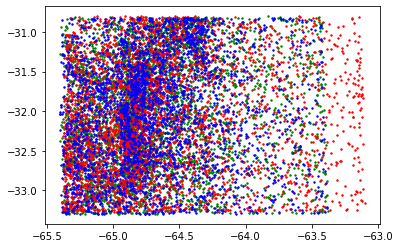

In [23]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

## Count number of tracks per case date

In [24]:
def count_tracks_per_date(ds):
    """
    Count average number of tracks per case date with different conditions.
    
    For LASSO datasets: Average the number of tracks across ensemble members for each date.
    For OBS datasets: Count the number of tracks for each date.
    
    Args:
        ds: xarray.Dataset
            Track statistics dataset with 'tracks' dimension and 'start_basetime' coordinate
            
    Returns:
        results: dict
            Dictionary containing:
            - 'all': (avg, std) - all tracks
            - 'nonsplit': (avg, std) - tracks that do not start as a split
            - 'nonmerge': (avg, std) - tracks that do not end as a merge
            - 'nonsplit_nonmerge': (avg, std) - tracks that do not start as split AND do not end as merge
            Each tuple contains (avg_tracks_per_date, std_tracks_per_date) as pd.Series
    """
    # Check if this is a LASSO dataset (has 'case' or 'ensmember' variable)
    is_lasso = 'case' in ds.data_vars or 'ensmember' in ds.data_vars
    
    # Get split and merge track numbers
    start_split = ds['start_split_tracknumber'].values
    end_merge = ds['end_merge_tracknumber'].values
    
    # Define track indices for different conditions
    # Tracks that do not start as a split
    nonsplit_idx = np.where(np.isnan(start_split))[0]
    # Tracks that do not end as a merge
    nonmerge_idx = np.where(np.isnan(end_merge))[0]
    # Tracks that do not start as split AND do not end as merge
    nonsplit_nonmerge_idx = np.intersect1d(nonsplit_idx, nonmerge_idx)
    
    # Initialize results dictionary
    results = {}
    
    if is_lasso:
        # For LASSO: group by date and ensemble member, then average across members
        # Extract date from each track
        track_dates = pd.to_datetime(ds['date'].values).strftime('%Y-%m-%d')
        track_members = ds['ensmember'].values
        
        # Process each condition
        conditions = {
            'all': np.arange(len(track_dates)),
            'nonsplit': nonsplit_idx,
            'nonmerge': nonmerge_idx,
            'nonsplit_nonmerge': nonsplit_nonmerge_idx
        }
        
        for cond_name, idx in conditions.items():
            # Create a DataFrame with date, member, and track indices for this condition
            df = pd.DataFrame({
                'date': track_dates[idx],
                'ensmember': track_members[idx],
                'track_idx': idx
            })
            
            # Count tracks per date and ensemble member
            counts_per_member = df.groupby(['date', 'ensmember']).size()
            
            # Average and std across ensemble members for each date
            avg_tracks = counts_per_member.groupby('date').mean()
            std_tracks = counts_per_member.groupby('date').std().fillna(0)
            
            results[cond_name] = (avg_tracks, std_tracks)
        
    else:
        # For OBS: simply count tracks per date from start_basetime
        track_dates = ds['start_basetime'].dt.strftime('%Y-%m-%d')
        
        # Process each condition
        conditions = {
            'all': np.arange(len(track_dates)),
            'nonsplit': nonsplit_idx,
            'nonmerge': nonmerge_idx,
            'nonsplit_nonmerge': nonsplit_nonmerge_idx
        }
        
        for cond_name, idx in conditions.items():
            # Subset the dataset for this condition
            ds_subset = ds.isel(tracks=idx)
            track_dates_subset = ds_subset['start_basetime'].dt.strftime('%Y-%m-%d')
            
            avg_tracks = ds_subset['tracks'].groupby(track_dates_subset).count().to_series()
            # OBS has no ensemble members, so std is 0
            std_tracks = pd.Series(0, index=avg_tracks.index)
            
            results[cond_name] = (avg_tracks, std_tracks)
    
    return results

In [25]:
# Count average tracks per date for each dataset
results_o = count_tracks_per_date(ds_o)
results_o25 = count_tracks_per_date(ds_o25)
results_d2 = count_tracks_per_date(ds_d2)
results_d3 = count_tracks_per_date(ds_d3)
results_d4 = count_tracks_per_date(ds_d4)

# Extract 'all' tracks for backward compatibility
avg_tracks_o, std_tracks_o = results_o['all']
avg_tracks_o25, std_tracks_o25 = results_o25['all']
avg_tracks_d2, std_tracks_d2 = results_d2['all']
avg_tracks_d3, std_tracks_d3 = results_d3['all']
avg_tracks_d4, std_tracks_d4 = results_d4['all']

# Extract nonsplit tracks
avg_tracks_nonsplit_o, std_tracks_nonsplit_o = results_o['nonsplit']
avg_tracks_nonsplit_o25, std_tracks_nonsplit_o25 = results_o25['nonsplit']
avg_tracks_nonsplit_d2, std_tracks_nonsplit_d2 = results_d2['nonsplit']
avg_tracks_nonsplit_d3, std_tracks_nonsplit_d3 = results_d3['nonsplit']
avg_tracks_nonsplit_d4, std_tracks_nonsplit_d4 = results_d4['nonsplit']

# Extract nonmerge tracks
avg_tracks_nonmerge_o, std_tracks_nonmerge_o = results_o['nonmerge']
avg_tracks_nonmerge_o25, std_tracks_nonmerge_o25 = results_o25['nonmerge']
avg_tracks_nonmerge_d2, std_tracks_nonmerge_d2 = results_d2['nonmerge']
avg_tracks_nonmerge_d3, std_tracks_nonmerge_d3 = results_d3['nonmerge']
avg_tracks_nonmerge_d4, std_tracks_nonmerge_d4 = results_d4['nonmerge']

# Extract nonsplit_nonmerge tracks
avg_tracks_nonsplit_nonmerge_o, std_tracks_nonsplit_nonmerge_o = results_o['nonsplit_nonmerge']
avg_tracks_nonsplit_nonmerge_o25, std_tracks_nonsplit_nonmerge_o25 = results_o25['nonsplit_nonmerge']
avg_tracks_nonsplit_nonmerge_d2, std_tracks_nonsplit_nonmerge_d2 = results_d2['nonsplit_nonmerge']
avg_tracks_nonsplit_nonmerge_d3, std_tracks_nonsplit_nonmerge_d3 = results_d3['nonsplit_nonmerge']
avg_tracks_nonsplit_nonmerge_d4, std_tracks_nonsplit_nonmerge_d4 = results_d4['nonsplit_nonmerge']

# Sum over all dates to get total tracks
total_tracks_o = avg_tracks_o.sum()
total_tracks_o25 = avg_tracks_o25.sum()
total_tracks_d2 = avg_tracks_d2.sum()
total_tracks_d3 = avg_tracks_d3.sum()
total_tracks_d4 = avg_tracks_d4.sum()

total_tracks_nonsplit_o = avg_tracks_nonsplit_o.sum()
total_tracks_nonsplit_o25 = avg_tracks_nonsplit_o25.sum()
total_tracks_nonsplit_d2 = avg_tracks_nonsplit_d2.sum()
total_tracks_nonsplit_d3 = avg_tracks_nonsplit_d3.sum()
total_tracks_nonsplit_d4 = avg_tracks_nonsplit_d4.sum()

total_tracks_nonmerge_o = avg_tracks_nonmerge_o.sum()
total_tracks_nonmerge_o25 = avg_tracks_nonmerge_o25.sum()
total_tracks_nonmerge_d2 = avg_tracks_nonmerge_d2.sum()
total_tracks_nonmerge_d3 = avg_tracks_nonmerge_d3.sum()
total_tracks_nonmerge_d4 = avg_tracks_nonmerge_d4.sum()

total_tracks_nonsplit_nonmerge_o = avg_tracks_nonsplit_nonmerge_o.sum()
total_tracks_nonsplit_nonmerge_o25 = avg_tracks_nonsplit_nonmerge_o25.sum()
total_tracks_nonsplit_nonmerge_d2 = avg_tracks_nonsplit_nonmerge_d2.sum()
total_tracks_nonsplit_nonmerge_d3 = avg_tracks_nonsplit_nonmerge_d3.sum()
total_tracks_nonsplit_nonmerge_d4 = avg_tracks_nonsplit_nonmerge_d4.sum()

# Display results
print("="*60)
print("ALL TRACKS")
print("="*60)
print("Average tracks per date (OBS 500m):")
print(avg_tracks_o)
print(f"Mean: {avg_tracks_o.mean():.2f}, Std: {avg_tracks_o.std():.2f}")
print(f"Total tracks: {total_tracks_o:.1f}\n")

print("Average tracks per date (OBS 2.5km):")
print(avg_tracks_o25)
print(f"Mean: {avg_tracks_o25.mean():.2f}, Std: {avg_tracks_o25.std():.2f}")
print(f"Total tracks: {total_tracks_o25:.1f}\n")

print("Average tracks per date (LASSO D2 2.5km):")
print(avg_tracks_d2)
print(f"Mean: {avg_tracks_d2.mean():.2f}, Std: {avg_tracks_d2.std():.2f}")
print(f"Total tracks: {total_tracks_d2:.1f}\n")

print("Average tracks per date (LASSO D3 500m):")
print(avg_tracks_d3)
print(f"Mean: {avg_tracks_d3.mean():.2f}, Std: {avg_tracks_d3.std():.2f}")
print(f"Total tracks: {total_tracks_d3:.1f}\n")

print("Average tracks per date (LASSO D4 100m):")
print(avg_tracks_d4)
print(f"Mean: {avg_tracks_d4.mean():.2f}, Std: {avg_tracks_d4.std():.2f}")
print(f"Total tracks: {total_tracks_d4:.1f}\n")

print("="*60)
print("NONSPLIT TRACKS (do not start as split)")
print("="*60)
print(f"Total nonsplit tracks - OBS 500m: {total_tracks_nonsplit_o:.1f}")
print(f"Total nonsplit tracks - OBS 2.5km: {total_tracks_nonsplit_o25:.1f}")
print(f"Total nonsplit tracks - LASSO D2 2.5km: {total_tracks_nonsplit_d2:.1f}")
print(f"Total nonsplit tracks - LASSO D3 500m: {total_tracks_nonsplit_d3:.1f}")
print(f"Total nonsplit tracks - LASSO D4 100m: {total_tracks_nonsplit_d4:.1f}\n")

print("="*60)
print("NONMERGE TRACKS (do not end as merge)")
print("="*60)
print(f"Total nonmerge tracks - OBS 500m: {total_tracks_nonmerge_o:.1f}")
print(f"Total nonmerge tracks - OBS 2.5km: {total_tracks_nonmerge_o25:.1f}")
print(f"Total nonmerge tracks - LASSO D2 2.5km: {total_tracks_nonmerge_d2:.1f}")
print(f"Total nonmerge tracks - LASSO D3 500m: {total_tracks_nonmerge_d3:.1f}")
print(f"Total nonmerge tracks - LASSO D4 100m: {total_tracks_nonmerge_d4:.1f}\n")

print("="*60)
print("NONSPLIT & NONMERGE TRACKS")
print("="*60)
print(f"Total nonsplit & nonmerge tracks - OBS 500m: {total_tracks_nonsplit_nonmerge_o:.1f}")
print(f"Total nonsplit & nonmerge tracks - OBS 2.5km: {total_tracks_nonsplit_nonmerge_o25:.1f}")
print(f"Total nonsplit & nonmerge tracks - LASSO D2 2.5km: {total_tracks_nonsplit_nonmerge_d2:.1f}")
print(f"Total nonsplit & nonmerge tracks - LASSO D3 500m: {total_tracks_nonsplit_nonmerge_d3:.1f}")
print(f"Total nonsplit & nonmerge tracks - LASSO D4 100m: {total_tracks_nonsplit_nonmerge_d4:.1f}")

ALL TRACKS
Average tracks per date (OBS 500m):
strftime
2018-11-29     60
2018-12-04     49
2018-12-05    119
2019-01-22     28
2019-01-23     85
2019-01-25     84
2019-01-29     57
2019-02-08     42
Name: tracks, dtype: int64
Mean: 65.50, Std: 29.08
Total tracks: 524.0

Average tracks per date (OBS 2.5km):
strftime
2018-11-29     58
2018-12-04     45
2018-12-05    114
2019-01-22     33
2019-01-23     75
2019-01-25     71
2019-01-29     54
2019-02-08     32
Name: tracks, dtype: int64
Mean: 60.25, Std: 26.83
Total tracks: 482.0

Average tracks per date (LASSO D2 2.5km):
date
2018-11-29    165.75
2018-12-04    173.00
2018-12-05    156.00
2019-01-22    134.50
2019-01-23    359.00
2019-01-25    107.00
2019-01-29    174.00
2019-02-08    186.50
dtype: float64
Mean: 181.97, Std: 75.89
Total tracks: 1455.8

Average tracks per date (LASSO D3 500m):
date
2018-11-29    220.0
2018-12-04    230.5
2018-12-05    228.0
2019-01-22    143.5
2019-01-23    566.0
2019-01-25    179.5
2019-01-29    263.5
201

### Plot number of tracks per case date

In [26]:
def plot_bars_tracks(bar_data, xlabel=None, ylabel=None, title=None, width=0.14, legend_loc='best',
                     figsize=None, figname=None, fontsize=12, error_data=None):
    """
    Plot bar chart for track counts per date.
    
    Args:
        bar_data: dict
            Dictionary with keys 'obs', 'obs25', 'd2', 'd3', 'd4' containing track counts
        xlabel: list
            List of x-axis labels (dates)
        ylabel: str
            Y-axis label
        title: str
            Plot title
        width: float (optional, default=0.16)
            Width of each bar
        legend_loc: str (optional, default='best')
            Location of the legend
        figsize: tuple
            Figure size
        figname: str
            Output filename
        fontsize: int
            Font size for plot
        error_data: dict (optional)
            Dictionary with keys 'obs', 'obs25', 'd2', 'd3', 'd4' containing error bar values (std)
    """
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'

    x = np.arange(len(xlabel))  # the label locations
    # width = 0.16  # the width of the bars
    
    # Define colors
    lcolors = {
        'obs': 'black',
        'obs25': 'gray',
        'd2': 'dodgerblue',
        'd3': 'seagreen',
        'd4': 'darkviolet'
    }
    
    name_map = {
        'obs': 'OBS 500 m',
        'obs25': 'OBS 2.5 km',
        'd2': 'LASSO 2.5 km',
        'd3': 'LASSO 500 m',
        'd4': 'LASSO 100 m'
    }

    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    
    # Prepare error bar data if provided
    if error_data is not None:
        err_obs = error_data['obs']
        err_obs25 = error_data['obs25']
        err_d2 = error_data['d2']
        err_d3 = error_data['d3']
        err_d4 = error_data['d4']
    else:
        err_obs = err_obs25 = err_d2 = err_d3 = err_d4 = None
    
    # Plot bars with offset and error bars
    bars_obs = ax.bar(x - 2*width, bar_data['obs'], width, label=name_map['obs'], color=lcolors['obs'], yerr=err_obs, capsize=3)
    bars_obs25 = ax.bar(x - width, bar_data['obs25'], width, label=name_map['obs25'], color=lcolors['obs25'], yerr=err_obs25, capsize=3)
    bars_d2 = ax.bar(x, bar_data['d2'], width, label=name_map['d2'], color=lcolors['d2'], yerr=err_d2, capsize=3)
    bars_d3 = ax.bar(x + width, bar_data['d3'], width, label=name_map['d3'], color=lcolors['d3'], yerr=err_d3, capsize=3)
    bars_d4 = ax.bar(x + 2*width, bar_data['d4'], width, label=name_map['d4'], color=lcolors['d4'], yerr=err_d4, capsize=3)

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    ax.set_xticks(x)
    ax.set_xticklabels(xlabel, rotation=30, ha='right')
    ax.grid(ls=':', axis='y')
    ax.legend(loc=legend_loc)

    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

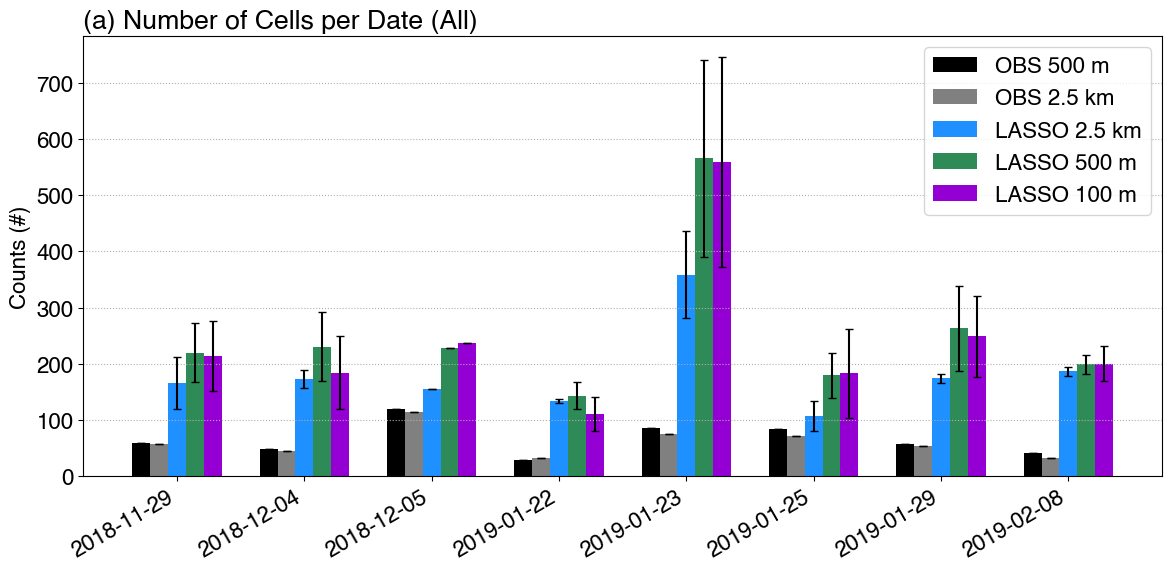

In [27]:
# Prepare data for bar chart
# Get all unique dates from all datasets
all_dates = sorted(set(list(avg_tracks_o.index) + list(avg_tracks_o25.index) + 
                       list(avg_tracks_d2.index) + list(avg_tracks_d3.index) + 
                       list(avg_tracks_d4.index)))

# Create bar_data dictionary, filling missing dates with 0
bar_data = {
    'obs': [avg_tracks_o.get(date, 0) for date in all_dates],
    'obs25': [avg_tracks_o25.get(date, 0) for date in all_dates],
    'd2': [avg_tracks_d2.get(date, 0) for date in all_dates],
    'd3': [avg_tracks_d3.get(date, 0) for date in all_dates],
    'd4': [avg_tracks_d4.get(date, 0) for date in all_dates],
}

# Create error_data dictionary with standard deviations
error_data = {
    'obs': [std_tracks_o.get(date, 0) for date in all_dates],
    'obs25': [std_tracks_o25.get(date, 0) for date in all_dates],
    'd2': [std_tracks_d2.get(date, 0) for date in all_dates],
    'd3': [std_tracks_d3.get(date, 0) for date in all_dates],
    'd4': [std_tracks_d4.get(date, 0) for date in all_dates],
}

width=0.14

# Create the bar chart
figname = f'{figdir}celltrack_counts_per_date_barplot.png'
fig = plot_bars_tracks(
    bar_data=bar_data,
    xlabel=all_dates,
    ylabel='Counts (#)',
    title='(a) Number of Cells per Date (All)',
    width=width,
    legend_loc='best',
    figsize=(12, 6),
    figname=figname,
    fontsize=16,
    error_data=error_data
)

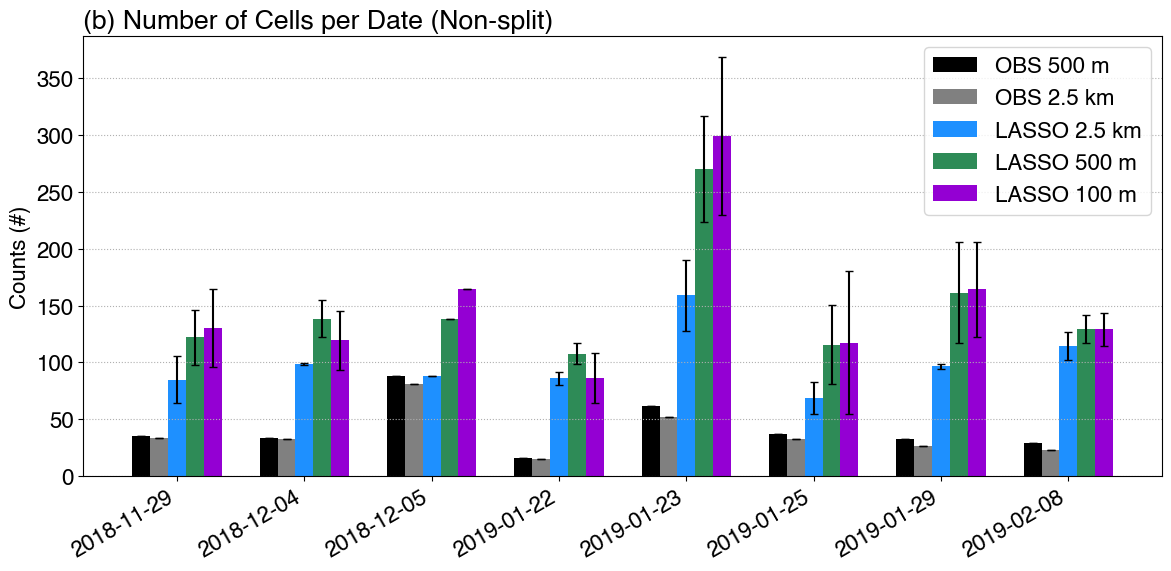

In [ ]:
# Prepare data for bar chart
# Get all unique dates from all datasets
all_dates = sorted(set(list(avg_tracks_nonsplit_o.index) + list(avg_tracks_nonsplit_o25.index) + 
                       list(avg_tracks_nonsplit_d2.index) + list(avg_tracks_nonsplit_d3.index) + 
                       list(avg_tracks_nonsplit_d4.index)))

# Create bar_data dictionary, filling missing dates with 0
bar_data = {
    'obs': [avg_tracks_nonsplit_o.get(date, 0) for date in all_dates],
    'obs25': [avg_tracks_nonsplit_o25.get(date, 0) for date in all_dates],
    'd2': [avg_tracks_nonsplit_d2.get(date, 0) for date in all_dates],
    'd3': [avg_tracks_nonsplit_d3.get(date, 0) for date in all_dates],
    'd4': [avg_tracks_nonsplit_d4.get(date, 0) for date in all_dates],
}

# Create error_data dictionary with standard deviations
error_data = {
    'obs': [std_tracks_nonsplit_o.get(date, 0) for date in all_dates],
    'obs25': [std_tracks_nonsplit_o25.get(date, 0) for date in all_dates],
    'd2': [std_tracks_nonsplit_d2.get(date, 0) for date in all_dates],
    'd3': [std_tracks_nonsplit_d3.get(date, 0) for date in all_dates],
    'd4': [std_tracks_nonsplit_d4.get(date, 0) for date in all_dates],
}

width=0.14

# Create the bar chart
figname = f'{figdir}celltrack_counts_per_date_barplot_nonsplit.png'
fig = plot_bars_tracks(
    bar_data=bar_data,
    xlabel=all_dates,
    ylabel='Counts (#)',
    title='(b) Number of Cells per Date (Non-split)',
    width=width,
    figsize=(12, 6),
    figname=figname,
    fontsize=16,
    error_data=error_data
)

In [29]:
total_tracks_o, total_tracks_o25, total_tracks_d2, total_tracks_d3, total_tracks_d4

(524, 482, 1455.75, 2030.0, 1938.75)

## Get variables for analysis

In [ ]:
end_merge_tracknumber_o25 = ds_o25['end_merge_tracknumber']
start_split_tracknumber_o25 = ds_o25['start_split_tracknumber']
cell_lon_o25 = ds_o25['cell_meanlon']
cell_lat_o25 = ds_o25['cell_meanlat']

In [ ]:
end_merge_tracknumber_o = ds_o['end_merge_tracknumber']
start_split_tracknumber_o = ds_o['start_split_tracknumber']
cell_lon_o = ds_o['cell_meanlon']
cell_lat_o = ds_o['cell_meanlat']

In [ ]:
end_merge_tracknumber_d2 = ds_d2['end_merge_tracknumber']
start_split_tracknumber_d2 = ds_d2['start_split_tracknumber']
cell_lon_d2 = ds_d2['cell_meanlon']
cell_lat_d2 = ds_d2['cell_meanlat']

In [ ]:
end_merge_tracknumber_d3 = ds_d3['end_merge_tracknumber']
start_split_tracknumber_d3 = ds_d3['start_split_tracknumber']
cell_lon_d3 = ds_d3['cell_meanlon']
cell_lat_d3 = ds_d3['cell_meanlat']

In [ ]:
end_merge_tracknumber_d4 = ds_d4['end_merge_tracknumber']
start_split_tracknumber_d4 = ds_d4['start_split_tracknumber']
cell_lon_d4 = ds_d4['cell_meanlon']
cell_lat_d4 = ds_d4['cell_meanlat']

## Find merge/split tracks

In [35]:
# Find tracks not end with merge or not start with split
nonmerge_o25 = np.where(np.isnan(end_merge_tracknumber_o25))[0]
nonsplit_o25 = np.where(np.isnan(start_split_tracknumber_o25))[0]
ntracks_nonmerge_o25 = len(nonmerge_o25)
ntracks_nonsplit_o25 = len(nonsplit_o25)
print(f'Number of non-merge tracks (OBS 2.5km): {ntracks_nonmerge_o25}')
print(f'Number of non-split tracks (OBS 2.5km): {ntracks_nonsplit_o25}')

merge_o25 = np.where(end_merge_tracknumber_o25 > 0)[0]
split_o25 = np.where(start_split_tracknumber_o25 > 0)[0]
ntracks_merge_o25 = len(merge_o25)
ntracks_split_o25 = len(split_o25)
print(f'Number of merge tracks (OBS 2.5km): {ntracks_merge_o25}')
print(f'Number of split tracks (OBS 2.5km): {ntracks_split_o25}')

Number of non-merge tracks (OBS 2.5km): 324
Number of non-split tracks (OBS 2.5km): 298
Number of merge tracks (OBS 2.5km): 158
Number of split tracks (OBS 2.5km): 184


In [36]:
# Find tracks not end with merge or not start with split
nonmerge_o = np.where(np.isnan(end_merge_tracknumber_o))[0]
nonsplit_o = np.where(np.isnan(start_split_tracknumber_o))[0]
ntracks_nonmerge_o = len(nonmerge_o)
ntracks_nonsplit_o = len(nonsplit_o)
print(f'Number of non-merge tracks (OBS): {ntracks_nonmerge_o}')
print(f'Number of non-split tracks (OBS): {ntracks_nonsplit_o}')

merge_o = np.where(end_merge_tracknumber_o > 0)[0]
split_o = np.where(start_split_tracknumber_o > 0)[0]
ntracks_merge_o = len(merge_o)
ntracks_split_o = len(split_o)
print(f'Number of merge tracks (OBS): {ntracks_merge_o}')
print(f'Number of split tracks (OBS): {ntracks_split_o}')

Number of non-merge tracks (OBS): 375
Number of non-split tracks (OBS): 334
Number of merge tracks (OBS): 149
Number of split tracks (OBS): 190


In [37]:
# Find tracks not end with merge or not start with split
nonmerge_d2 = np.where(np.isnan(end_merge_tracknumber_d2))[0]
nonsplit_d2 = np.where(np.isnan(start_split_tracknumber_d2))[0]
ntracks_nonmerge_d2 = len(nonmerge_d2)
ntracks_nonsplit_d2 = len(nonsplit_d2)
print(f'Number of non-merge tracks (d2): {ntracks_nonmerge_d2}')
print(f'Number of non-split tracks (d2): {ntracks_nonsplit_d2}')

merge_d2 = np.where(end_merge_tracknumber_d2 > 0)[0]
split_d2 = np.where(start_split_tracknumber_d2 > 0)[0]
ntracks_merge_d2 = len(merge_d2)
ntracks_split_d2 = len(split_d2)
print(f'Number of merge tracks (d2): {ntracks_merge_d2}')
print(f'Number of split tracks (d2): {ntracks_split_d2}')

Number of non-merge tracks (d2): 1664
Number of non-split tracks (d2): 1675
Number of merge tracks (d2): 1423
Number of split tracks (d2): 1412


In [38]:
# Find tracks not end with merge or not start with split
nonmerge_d3 = np.where(np.isnan(end_merge_tracknumber_d3))[0]
nonsplit_d3 = np.where(np.isnan(start_split_tracknumber_d3))[0]
ntracks_nonmerge_d3 = len(nonmerge_d3)
ntracks_nonsplit_d3 = len(nonsplit_d3)
print(f'Number of non-merge tracks (D3): {ntracks_nonmerge_d3}')
print(f'Number of non-split tracks (D3): {ntracks_nonsplit_d3}')

merge_d3 = np.where(end_merge_tracknumber_d3 > 0)[0]
split_d3 = np.where(start_split_tracknumber_d3 > 0)[0]
ntracks_merge_d3 = len(merge_d3)
ntracks_split_d3 = len(split_d3)
print(f'Number of merge tracks (D3): {ntracks_merge_d3}')
print(f'Number of split tracks (D3): {ntracks_split_d3}')

Number of non-merge tracks (D3): 2454
Number of non-split tracks (D3): 2472
Number of merge tracks (D3): 1818
Number of split tracks (D3): 1800


In [39]:
# Find tracks not end with merge or not start with split
nonmerge_d4 = np.where(np.isnan(end_merge_tracknumber_d4))[0]
nonsplit_d4 = np.where(np.isnan(start_split_tracknumber_d4))[0]
ntracks_nonmerge_d4 = len(nonmerge_d4)
ntracks_nonsplit_d4 = len(nonsplit_d4)
print(f'Number of non-merge tracks (D4): {ntracks_nonmerge_d4}')
print(f'Number of non-split tracks (D4): {ntracks_nonsplit_d4}')

merge_d4 = np.where(end_merge_tracknumber_d4 > 0)[0]
split_d4 = np.where(start_split_tracknumber_d4 > 0)[0]
ntracks_merge_d4 = len(merge_d4)
ntracks_split_d4 = len(split_d4)
print(f'Number of merge tracks (D4): {ntracks_merge_d4}')
print(f'Number of split tracks (D4): {ntracks_split_d4}')

Number of non-merge tracks (D4): 2417
Number of non-split tracks (D4): 2518
Number of merge tracks (D4): 1651
Number of split tracks (D4): 1550


## Get cell initiation locations

In [40]:
start_lon_o = cell_lon_o.isel(times=0)
start_lat_o = cell_lat_o.isel(times=0)
start_lon_nonsplit_o = cell_lon_o.isel(tracks=nonsplit_o, times=0)
start_lat_nonsplit_o = cell_lat_o.isel(tracks=nonsplit_o, times=0)

In [41]:
start_lon_o25 = cell_lon_o25.isel(times=0)
start_lat_o25 = cell_lat_o25.isel(times=0)
start_lon_nonsplit_o25 = cell_lon_o25.isel(tracks=nonsplit_o25, times=0)
start_lat_nonsplit_o25 = cell_lat_o25.isel(tracks=nonsplit_o25, times=0)

In [42]:
start_lon_d2 = cell_lon_d2.isel(times=0)
start_lat_d2 = cell_lat_d2.isel(times=0)
start_lon_nonsplit_d2 = cell_lon_d2.isel(tracks=nonsplit_d2, times=0)
start_lat_nonsplit_d2 = cell_lat_d2.isel(tracks=nonsplit_d2, times=0)

In [43]:
start_lon_d3 = cell_lon_d3.isel(times=0)
start_lat_d3 = cell_lat_d3.isel(times=0)
start_lon_nonsplit_d3 = cell_lon_d3.isel(tracks=nonsplit_d3, times=0)
start_lat_nonsplit_d3 = cell_lat_d3.isel(tracks=nonsplit_d3, times=0)

In [44]:
start_lon_d4 = cell_lon_d4.isel(times=0)
start_lat_d4 = cell_lat_d4.isel(times=0)
start_lon_nonsplit_d4 = cell_lon_d4.isel(tracks=nonsplit_d4, times=0)
start_lat_nonsplit_d4 = cell_lat_d4.isel(tracks=nonsplit_d4, times=0)

## Calculate spatial map of initiation locations

In [45]:
# Set domain boundary based on overlap area between OBS and D4
minlon, maxlon = -65.4, -63.5
minlat, maxlat = -33.1, -31.1
buffer = 0.05
# bins = [24, 24]
ranges = [[minlon+buffer,maxlon-buffer], [minlat+buffer,maxlat-buffer]]

lonbins = np.arange(minlon, maxlon, 0.1)
latbins = np.arange(minlat, maxlat, 0.1)
bins = [lonbins, latbins]

In [46]:
hist2d_startloc_o25, xbins, ybins = np.histogram2d(start_lon_o25.values, start_lat_o25.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_o25, xbins, ybins = np.histogram2d(start_lon_nonsplit_o25.values, start_lat_nonsplit_o25.values, bins=bins, range=ranges)
hist2d_startloc_o25 = hist2d_startloc_o25.transpose()
hist2d_startloc_nonsplit_o25 = hist2d_startloc_nonsplit_o25.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_o25 = 100 * hist2d_startloc_o25 / ntimes_o25
freq2d_startloc_nonsplit_o25 = 100 * hist2d_startloc_nonsplit_o25 / ntimes_o25

In [47]:
hist2d_startloc_o, xbins, ybins = np.histogram2d(start_lon_o.values, start_lat_o.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_o, xbins, ybins = np.histogram2d(start_lon_nonsplit_o.values, start_lat_nonsplit_o.values, bins=bins, range=ranges)
hist2d_startloc_o = hist2d_startloc_o.transpose()
hist2d_startloc_nonsplit_o = hist2d_startloc_nonsplit_o.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_o = 100 * hist2d_startloc_o / ntimes_o
freq2d_startloc_nonsplit_o = 100 * hist2d_startloc_nonsplit_o / ntimes_o

In [48]:
hist2d_startloc_d2, xbins, ybins = np.histogram2d(start_lon_d2.values, start_lat_d2.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d2, xbins, ybins = np.histogram2d(start_lon_nonsplit_d2.values, start_lat_nonsplit_d2.values, bins=bins, range=ranges)
hist2d_startloc_d2 = hist2d_startloc_d2.transpose()
hist2d_startloc_nonsplit_d2 = hist2d_startloc_nonsplit_d2.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_d2 = 100 * hist2d_startloc_d2 / ntimes_d2
freq2d_startloc_nonsplit_d2 = 100 * hist2d_startloc_nonsplit_d2 / ntimes_d2

In [49]:
hist2d_startloc_d3, xbins, ybins = np.histogram2d(start_lon_d3.values, start_lat_d3.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d3, xbins, ybins = np.histogram2d(start_lon_nonsplit_d3.values, start_lat_nonsplit_d3.values, bins=bins, range=ranges)
hist2d_startloc_d3 = hist2d_startloc_d3.transpose()
hist2d_startloc_nonsplit_d3 = hist2d_startloc_nonsplit_d3.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_d3 = 100 * hist2d_startloc_d3 / ntimes_d3
freq2d_startloc_nonsplit_d3 = 100 * hist2d_startloc_nonsplit_d3 / ntimes_d3

In [50]:
hist2d_startloc_d4, xbins, ybins = np.histogram2d(start_lon_d4.values, start_lat_d4.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d4, xbins, ybins = np.histogram2d(start_lon_nonsplit_d4.values, start_lat_nonsplit_d4.values, bins=bins, range=ranges)
hist2d_startloc_d4 = hist2d_startloc_d4.transpose()
hist2d_startloc_nonsplit_d4 = hist2d_startloc_nonsplit_d4.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_d4 = 100 * hist2d_startloc_d4 / ntimes_d4
freq2d_startloc_nonsplit_d4 = 100 * hist2d_startloc_nonsplit_d4 / ntimes_d4

## Plot all sources in a multi-panel figure

In [75]:
def plot_multipanel_heatmaps(nrow, ncol, dataarr, lonarr, latarr, topoZ, topoLon, topoLat, 
                             levels, cmaps, cmap_topo, cblabels, cbticks, titles, figname,
                             xticks_list=None, yticks_list=None, xlabel_list=None, ylabel_list=None,
                             show_legend_list=None, eSDC=None, oob_colors=None, 
                             figsize=[15.5, 10], fontsize=12, 
                             hspace=0.05, wspace=0.05, hspace_sub=0.15, wspace_sub=0.1):
    """
    Plot multiple heatmaps in a grid layout with a single vertical colorbar.
    
    Args:
        nrow: int
            Number of rows in the grid
        ncol: int
            Number of columns in the grid
        dataarr: list
            List of 2D arrays to plot (can contain None to skip panels)
        lonarr, latarr: arrays
            Coordinate arrays for plotting
        topoZ, topoLon, topoLat: arrays
            Topography data
        levels: array-like
            Contour levels for colorbar
        cmaps: str or colormap
            Colormap name
        cmap_topo: str or colormap
            Colormap for topography
        cblabels: str
            Colorbar label
        cbticks: array-like
            Colorbar tick locations
        titles: list
            List of titles for each panel
        figname: str
            Output filename
        xticks_list: list of arrays (optional)
            Custom xticks for each panel
        yticks_list: list of arrays (optional)
            Custom yticks for each panel
        xlabel_list: list of str (optional)
            Custom xlabel for each panel
        ylabel_list: list of str (optional)
            Custom ylabel for each panel
        show_legend_list: list of bool (optional)
            Whether to show legend in each panel
        eSDC: float (optional)
            Vertical line position
        oob_colors: dict (optional)
            Out-of-bounds colors
        figsize: tuple
            Figure size
        fontsize: int
            Font size
        hspace: float
            Height space between main grid and colorbar
        wspace: float
            Width space between main grid and colorbar
        hspace_sub: float
            Height space between subpanels
        wspace_sub: float
            Width space between subpanels
    
    Returns:
        fig: matplotlib.figure.Figure
    """
    
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    # Create figure and main gridspec (1 row, 2 cols: plots and colorbar)
    fig = plt.figure(figsize=figsize, dpi=100)
    gs_main = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[20, 0.5], 
                                hspace=hspace, wspace=wspace)
    
    # Create subplot grid for the maps
    gs_maps = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs_main[0],
                                               hspace=hspace_sub, wspace=wspace_sub)
    
    marker_style = dict(color='k', linestyle='none', marker='o', markersize=12, markerfacecolor='red')
    topo_levs = [500, 1000, 1500, 2000, 2500]
    
    # Get colormap
    cmap = copy.copy(mpl.cm.get_cmap(cmaps))
    norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
    
    # Set out of bound colors if provided
    if oob_colors is not None:
        cmap.set_over(oob_colors['over'])
        cmap.set_under(oob_colors['under'])
    
    # Plot each panel
    plot_idx = 0
    pcm = None
    
    for row in range(nrow):
        for col in range(ncol):
            if plot_idx >= len(dataarr) or dataarr[plot_idx] is None:
                plot_idx += 1
                continue
            
            # Create subplot
            ax = fig.add_subplot(gs_maps[row, col])
            
            # Mask zeros
            Zm = np.ma.masked_where(dataarr[plot_idx] == 0, dataarr[plot_idx])
            
            # Plot data
            pcm = ax.pcolormesh(lonarr, latarr, Zm, norm=norm, cmap=cmap)
            
            # Plot topography contours
            ax.contour(topoLon, topoLat, topoZ, levels=topo_levs, cmap=cmap_topo, linewidths=1.5)
            
            # Plot radar location
            ax.plot(radar_lon, radar_lat, **marker_style)
            
            # Set limits
            ax.set_xlim(np.min(lonarr), np.max(lonarr))
            ax.set_ylim(np.min(latarr), np.max(latarr))
            
            # Set aspect ratio to equal
            ax.set_aspect('equal', adjustable='box')
            
            # Set title
            if titles and plot_idx < len(titles):
                ax.set_title(titles[plot_idx], loc='left', fontweight='bold')
            
            # Set xticks
            if xticks_list and plot_idx < len(xticks_list):
                if xticks_list[plot_idx] is not None:
                    ax.set_xticks(xticks_list[plot_idx])
                else:
                    # Hide tick labels but keep ticks for gridlines
                    ax.set_xticks(np.arange(-65., np.max(lonarr), 0.5))
                    ax.set_xticklabels([])
            else:
                ax.set_xticks(np.arange(-65., np.max(lonarr), 0.5))
            
            # Set yticks
            if yticks_list and plot_idx < len(yticks_list):
                if yticks_list[plot_idx] is not None:
                    ax.set_yticks(yticks_list[plot_idx])
                else:
                    # Hide tick labels but keep ticks for gridlines
                    ax.set_yticks(np.arange(-33, np.max(latarr), 0.5))
                    ax.set_yticklabels([])
            else:
                ax.set_yticks(np.arange(-33, np.max(latarr), 0.5))
            
            # Set xlabel
            if xlabel_list and plot_idx < len(xlabel_list) and xlabel_list[plot_idx] is not None:
                ax.set_xlabel(xlabel_list[plot_idx])
            elif row == nrow - 1:  # Only bottom row
                ax.set_xlabel('Longitude')
            
            # Set ylabel
            if ylabel_list and plot_idx < len(ylabel_list) and ylabel_list[plot_idx] is not None:
                ax.set_ylabel(ylabel_list[plot_idx])
            elif col == 0:  # Only leftmost column
                ax.set_ylabel('Latitude')
            
            # Add grid
            ax.grid(ls='--')
            
            # Add vertical line if specified
            if eSDC is not None:
                ax.axvline(x=eSDC, color='magenta', lw=2)
            
            # Add legend
            show_legend = True
            if show_legend_list and plot_idx < len(show_legend_list):
                show_legend = show_legend_list[plot_idx]
            
            if show_legend:
                custom_lines = [mpl.lines.Line2D([0], [0], color=plt.get_cmap(cmap_topo)(0.8), lw=2)]
                ax.legend(custom_lines, ['Terrain'], loc='upper right')
            
            plot_idx += 1
    
    # Add colorbar
    if pcm is not None:
        cax = fig.add_subplot(gs_main[1])
        cbar = fig.colorbar(pcm, cax=cax, ticks=cbticks, label=cblabels, extend='both')
    
    # Save figure
    fig.savefig(figname, bbox_inches='tight', facecolor='w', dpi=300)
    
    return fig

In [76]:
# Compute % bias in total number of tracks
tracks_bias_d2 = 100 * (total_tracks_d2 - total_tracks_o25) / total_tracks_o25
tracks_bias_d3 = 100 * (total_tracks_d3 - total_tracks_o) / total_tracks_o
tracks_bias_d4 = 100 * (total_tracks_d4 - total_tracks_o) / total_tracks_o

print(f"D2 track number bias: {tracks_bias_d2:.0f}%")
print(f"D3 track number bias: {tracks_bias_d3:.0f}%")
print(f"D4 track number bias: {tracks_bias_d4:.0f}%")

D2 track number bias: 202%
D3 track number bias: 287%
D4 track number bias: 270%


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/obs_lasso_evaluation/celltrack_startend_loc_freq_0.1deg_obs_d2_d3_d4.png


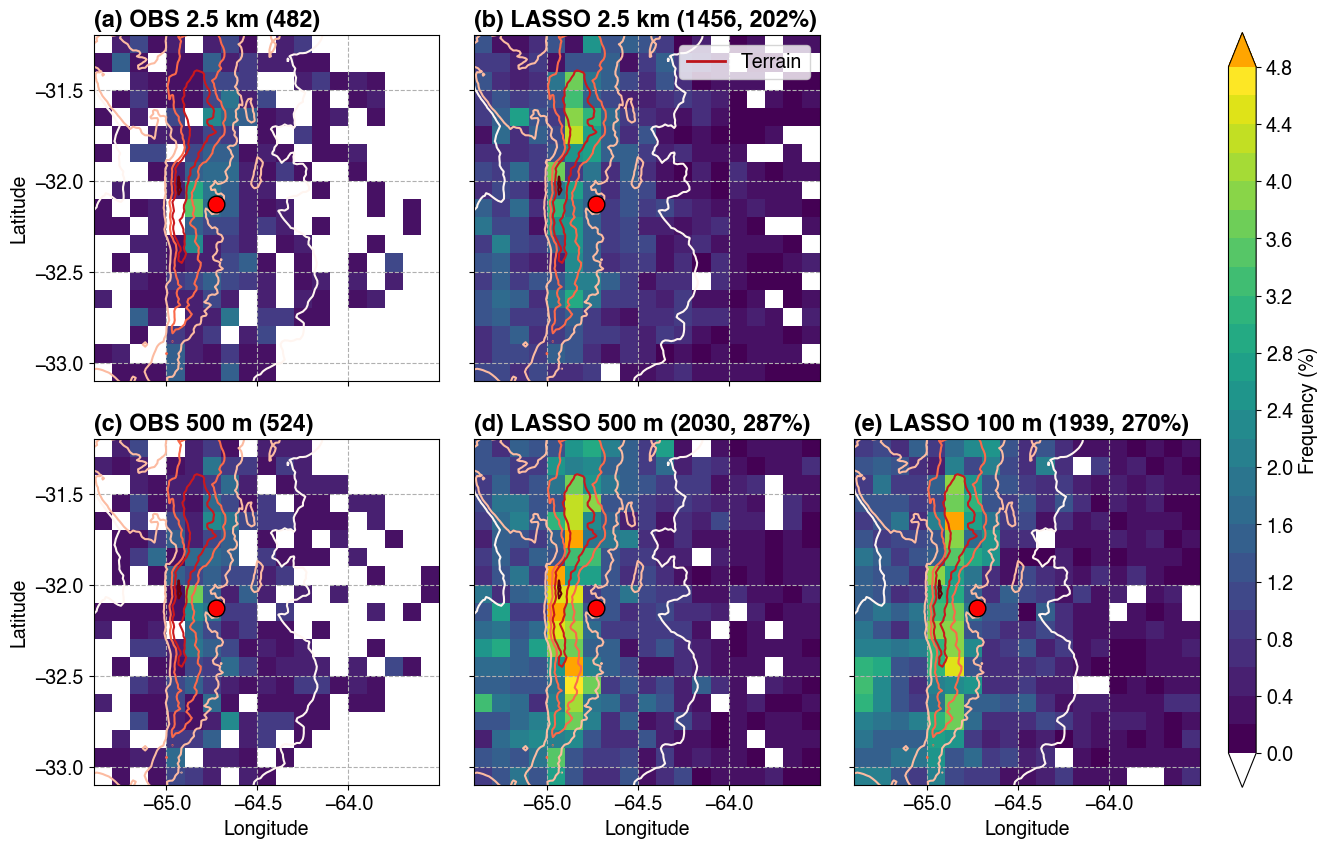

In [77]:
# Prepare data for multi-panel plot
# Row 1: OBS 2.5km, LASSO 2.5km, None (skip)
# Row 2: OBS 500m, LASSO 500m, LASSO 100m
dataarr_multi = [
    freq2d_startloc_o25, freq2d_startloc_d2, None,  # Row 1
    freq2d_startloc_o, freq2d_startloc_d3, freq2d_startloc_d4  # Row 2
]

titles_multi = [
    f"(a) OBS 2.5 km ({total_tracks_o25:.0f})", 
    f"(b) LASSO 2.5 km ({total_tracks_d2:.0f}, {tracks_bias_d2:.0f}%)", 
    None,
    f"(c) OBS 500 m ({total_tracks_o:.0f})", 
    f"(d) LASSO 500 m ({total_tracks_d3:.0f}, {tracks_bias_d3:.0f}%)", 
    f"(e) LASSO 100 m ({total_tracks_d4:.0f}, {tracks_bias_d4:.0f}%)"
]

xticks = np.arange(-65., maxlon, 0.5)
yticks = np.arange(-33, maxlat, 0.5)

# Show legend only in first panel of each row
show_legend_multi = [False, True, None, False, False, False]

# Labels for bottom row only
xlabel_multi = [None, None, None, 'Longitude', 'Longitude', 'Longitude']
xticks_multi = [None, None, None, xticks, xticks, xticks]

# Labels for leftmost column only
ylabel_multi = ['Latitude', None, None, 'Latitude', None, None]
yticks_multi = [yticks, None, None, yticks, None, None]

# Plot settings
levels = np.arange(0, 4.81, 0.2)
cbticks = np.arange(0, 4.81, 0.4)
cmap = 'viridis'
cmap_topo = 'Reds'
oob_colors = {'under': 'white', 'over': 'orange'}
cblabels = 'Frequency (%)'
figsize = [15, 10]
figname = f'{figdir}celltrack_startend_loc_freq_0.1deg_obs_d2_d3_d4.png'

fig = plot_multipanel_heatmaps(
    nrow=2, 
    ncol=3,
    dataarr=dataarr_multi,
    lonarr=xbins, 
    latarr=ybins,
    topoZ=topoZ, 
    topoLon=topoLon, 
    topoLat=topoLat,
    levels=levels,
    cmaps=cmap,
    cmap_topo=cmap_topo,
    cblabels=cblabels,
    cbticks=cbticks,
    titles=titles_multi,
    figname=figname,
    xlabel_list=xlabel_multi,
    ylabel_list=ylabel_multi,
    xticks_list=xticks_multi,
    yticks_list=yticks_multi,
    show_legend_list=show_legend_multi,
    oob_colors=oob_colors,
    figsize=figsize,
    fontsize=14,
    hspace=0.05,
    wspace=0.05,
    hspace_sub=0.15,
    wspace_sub=0.1
)

print(figname)

In [78]:
# Compute % bias in total number of tracks
tracks_bias_nonsplit_d2 = 100 * (total_tracks_nonsplit_d2 - total_tracks_nonsplit_o25) / total_tracks_nonsplit_o25
tracks_bias_nonsplit_d3 = 100 * (total_tracks_nonsplit_d3 - total_tracks_nonsplit_o) / total_tracks_nonsplit_o
tracks_bias_nonsplit_d4 = 100 * (total_tracks_nonsplit_d4 - total_tracks_nonsplit_o) / total_tracks_nonsplit_o

print(f"D2 non-split track number bias: {tracks_bias_nonsplit_d2:.0f}%")
print(f"D3 non-split track number bias: {tracks_bias_nonsplit_d3:.0f}%")
print(f"D4 non-split track number bias: {tracks_bias_nonsplit_d4:.0f}%")

D2 non-split track number bias: 167%
D3 non-split track number bias: 254%
D4 non-split track number bias: 263%


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/obs_lasso_evaluation/celltrack_startend_loc_nonsplit_freq_0.1deg_obs_d2_d3_d4.png


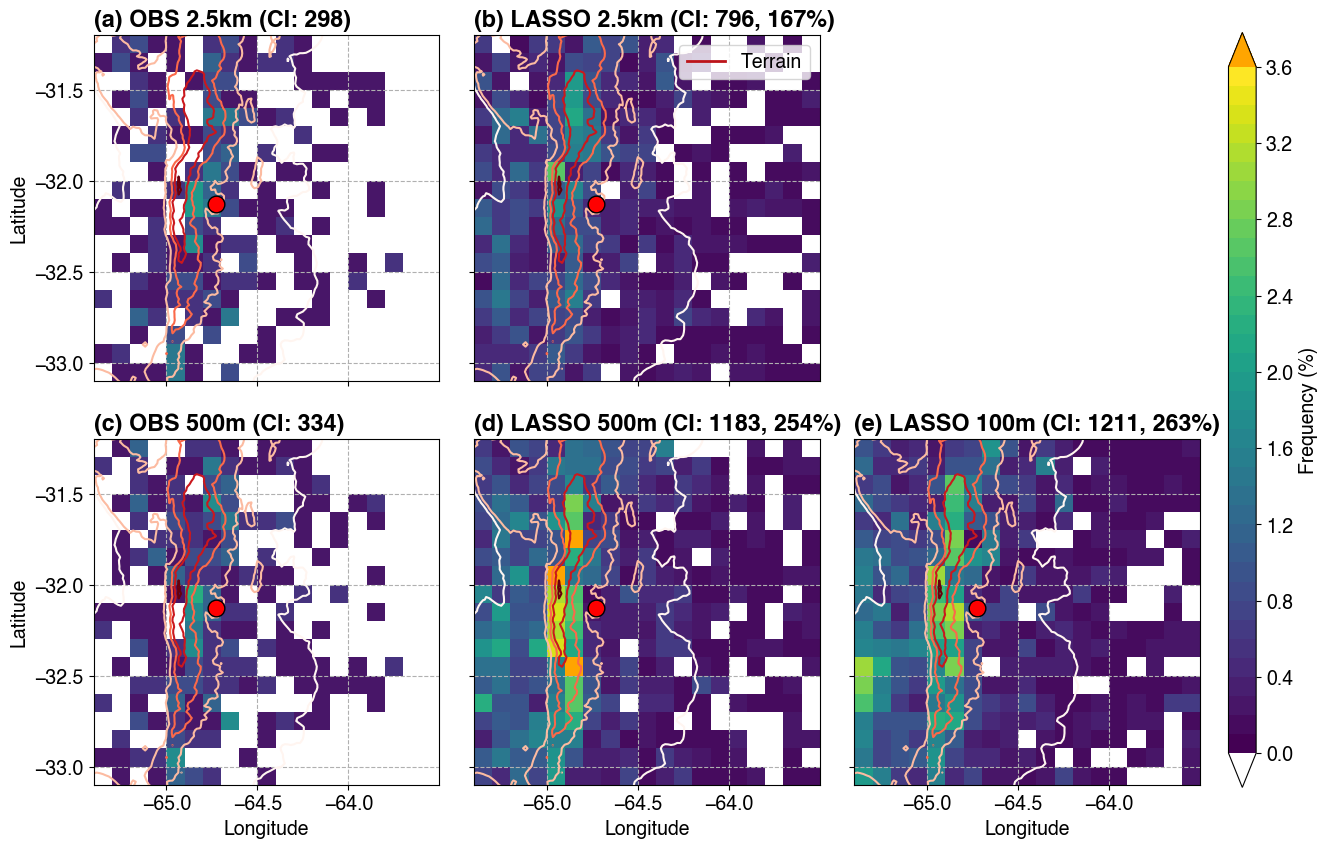

In [80]:
# Prepare data for multi-panel plot
# Row 1: OBS 2.5km, LASSO 2.5km, None (skip)
# Row 2: OBS 500m, LASSO 500m, LASSO 100m
dataarr_multi = [
    freq2d_startloc_nonsplit_o25, freq2d_startloc_nonsplit_d2, None,  # Row 1
    freq2d_startloc_nonsplit_o, freq2d_startloc_nonsplit_d3, freq2d_startloc_nonsplit_d4  # Row 2
]

titles_multi = [
    f"(a) OBS 2.5km (CI: {total_tracks_nonsplit_o25:.0f})", 
    f"(b) LASSO 2.5km (CI: {total_tracks_nonsplit_d2:.0f}, {tracks_bias_nonsplit_d2:.0f}%)", 
    None,
    f"(c) OBS 500m (CI: {total_tracks_nonsplit_o:.0f})", 
    f"(d) LASSO 500m (CI: {total_tracks_nonsplit_d3:.0f}, {tracks_bias_nonsplit_d3:.0f}%)", 
    f"(e) LASSO 100m (CI: {total_tracks_nonsplit_d4:.0f}, {tracks_bias_nonsplit_d4:.0f}%)"
]

xticks = np.arange(-65., maxlon, 0.5)
yticks = np.arange(-33, maxlat, 0.5)

# Show legend only in first panel of each row
show_legend_multi = [False, True, None, False, False, False]

# Labels for bottom row only
xlabel_multi = [None, None, None, 'Longitude', 'Longitude', 'Longitude']
xticks_multi = [None, None, None, xticks, xticks, xticks]

# Labels for leftmost column only
ylabel_multi = ['Latitude', None, None, 'Latitude', None, None]
yticks_multi = [yticks, None, None, yticks, None, None]

# Plot settings
# levels = np.arange(0, 4.81, 0.2)
# cbticks = np.arange(0, 4.81, 0.4)
levels = np.arange(0, 3.61, 0.1)
cbticks = np.arange(0, 3.61, 0.4)
cmap = 'viridis'
cmap_topo = 'Reds'
oob_colors = {'under': 'white', 'over': 'orange'}
cblabels = 'Frequency (%)'
figsize = [15, 10]
figname = f'{figdir}celltrack_startend_loc_nonsplit_freq_0.1deg_obs_d2_d3_d4.png'

fig = plot_multipanel_heatmaps(
    nrow=2, 
    ncol=3,
    dataarr=dataarr_multi,
    lonarr=xbins, 
    latarr=ybins,
    topoZ=topoZ, 
    topoLon=topoLon, 
    topoLat=topoLat,
    levels=levels,
    cmaps=cmap,
    cmap_topo=cmap_topo,
    cblabels=cblabels,
    cbticks=cbticks,
    titles=titles_multi,
    figname=figname,
    xlabel_list=xlabel_multi,
    ylabel_list=ylabel_multi,
    xticks_list=xticks_multi,
    yticks_list=yticks_multi,
    show_legend_list=show_legend_multi,
    oob_colors=oob_colors,
    figsize=figsize,
    fontsize=14,
    hspace=0.05,
    wspace=0.05,
    hspace_sub=0.15,
    wspace_sub=0.1
)

print(figname)